## Demo notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

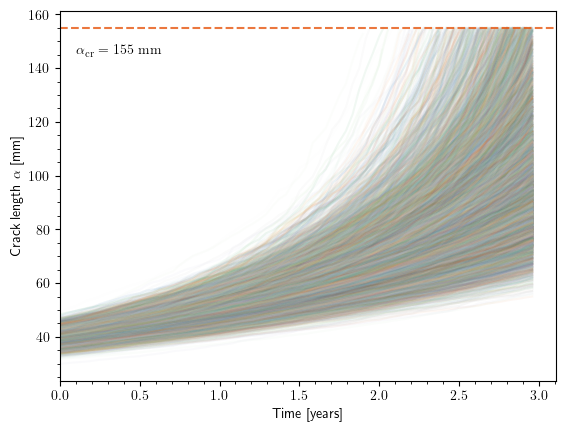

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

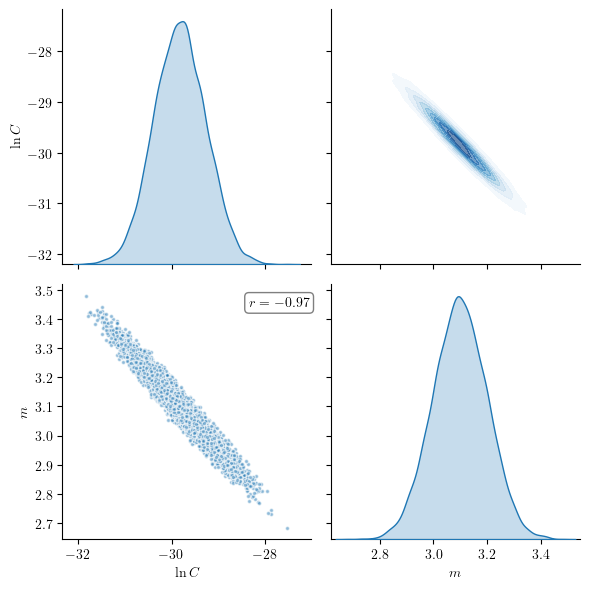

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

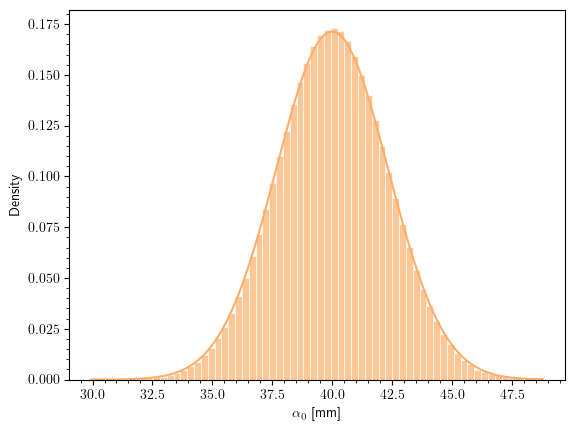

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

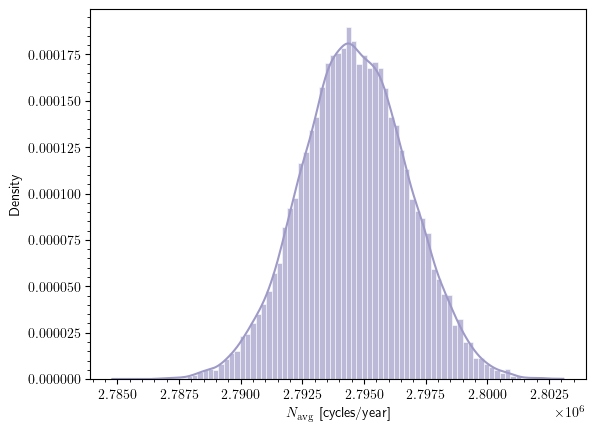

In [9]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

In [10]:
print(f"Average equivalent number of cycles for an approx. 3-year span: {data['avg_cycles'].mean() * data['times'].max():.2f}")
print(f"Assuming an 8-second average period, this is approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600:.2f} hours of operation.")
print(f"Or approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600 / (365 * 24):.2f} years of operation.")

Average equivalent number of cycles for an approx. 3-year span: 8268437.54
Assuming an 8-second average period, this is approximately 18374.31 hours of operation.
Or approximately 2.10 years of operation.


In [11]:
print(f"""Based on the data, the average period is approximately:
{(3*365.25*24*60*60)/(data['avg_cycles'].mean() * data['times'].max()):.2f} seconds.""")

Based on the data, the average period is approximately:
11.45 seconds.


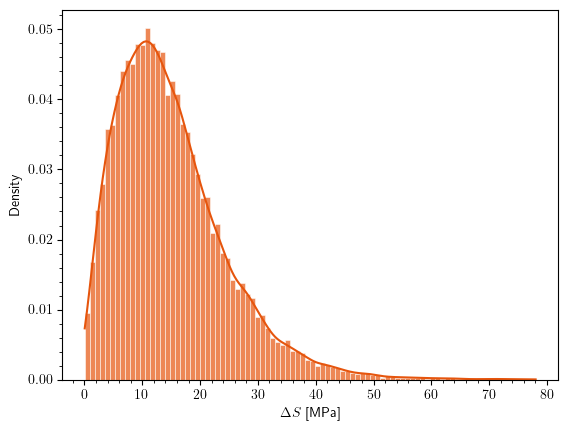

In [12]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

In [13]:
from src.visualisation import plot_paris_predictions
import numpy as np

In [14]:
# Randomly select instances to test the Paris law predictions
instances = np.random.randint(low=0, high=(data["times"].shape[0] - 1), size=10)
# Get the Paris law parameters for these instances
paris_params = (data["paris_c"][instances], data["paris_m"][instances])
# Get the initial crack lengths for these instances
initial_crack_lengths = data["initial_crack_length"][instances]
# Get the stress ranges for these instances
stress_ranges = np.linspace(10, 40, instances.shape[0])
# Use a common time array for all instances - using the first row of times
time_array = data["times"][0]
# Create array with the number of cycles for each instance
n_cycles = np.ones(instances.shape[0]) * np.mean(data["avg_cycles"][:, 0])

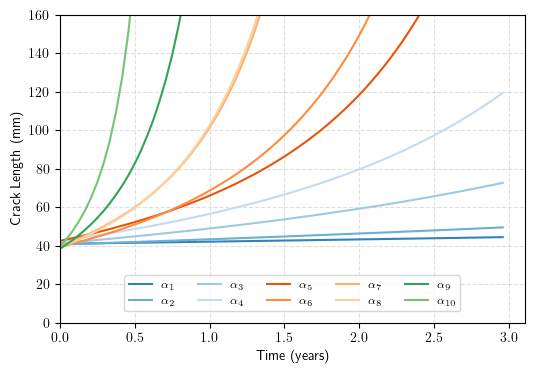

In [15]:
# Use our refactored function for plotting
fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=n_cycles,
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="paris_predictions.pdf",
    figsize=(6, 4),
    plot_grid=True
)

# We can add additional customization if needed
#ax.set_title("Paris Law Crack Growth Predictions for Multiple Instances")

Parameters for instance 585:
logC: -29.8888
m: 3.1280
ds: 23.3333
navg: 2793155.5950
a0: 42.4490


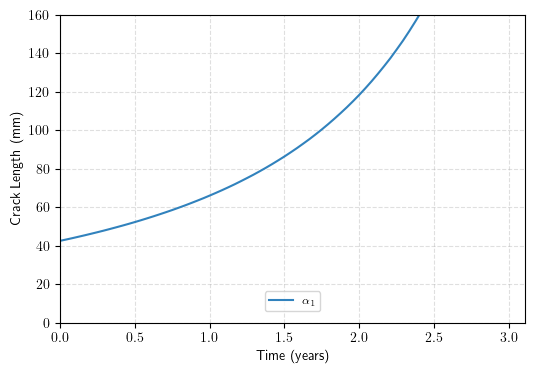

In [16]:
# Let's also test a single prediction to understand what's going on
inst = instances[4]
c = paris_params[0][4]
m = paris_params[1][4]
ds = stress_ranges[4]
navg = n_cycles[4]
a0 = initial_crack_lengths[4]

# Print these values to debug
print(f"Parameters for instance {inst}:")
print(f"logC: {np.log(c):.4f}")
print(f"m: {m:.4f}")
print(f"ds: {ds:.4f}")
print(f"navg: {navg:.4f}")
print(f"a0: {a0:.4f}")

# Plot a single instance prediction
fig, ax = plot_paris_predictions(
    paris_params=(c, m),
    ds=ds,
    navg=navg,
    a0=a0,
    times=time_array,
    figsize=(6, 4)
)

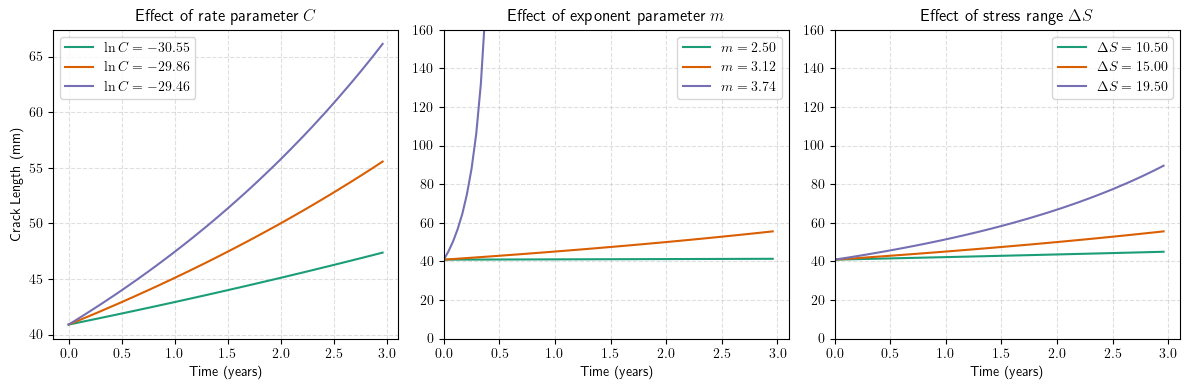

In [17]:
# Let's also explore how different parameters affect crack growth
from src.visualisation import plot_parameter_sensitivity

# Create baseline parameters
base_c = paris_params[0][0]
base_m = paris_params[1][0]
base_ds = 15.0
base_navg = n_cycles[0]
base_a0 = initial_crack_lengths[0]

# Use the new modular function for parameter sensitivity analysis
fig, axes = plot_parameter_sensitivity(
    base_c=base_c,
    base_m=base_m,
    base_ds=base_ds,
    base_navg=base_navg,
    base_a0=base_a0,
    times=time_array,
    save_fig_name="parameter_sensitivity.pdf",
)

# You can still customize the plot if needed
# axes[1].set_ylim(bottom=0, top=160)

## Testing Variable Stress Paris-Erdogan Model

This section demonstrates how to use the `VariableStressParisErdogan` model for simulating crack growth with time-varying stress ranges.

Average stress: 17.00 MPa
Stress range: 5.0 - 30.0 MPa


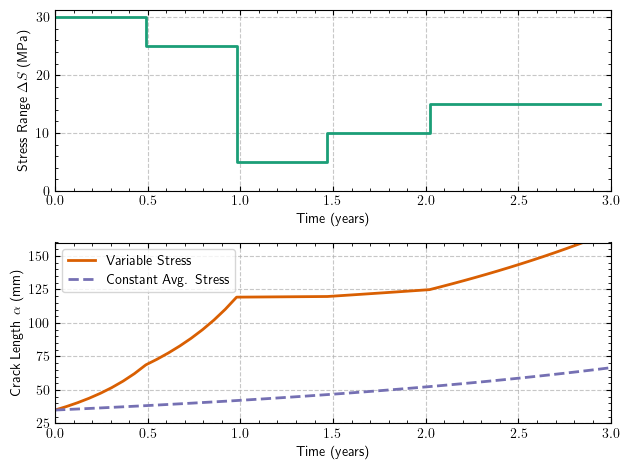

In [18]:
from src.visualisation import plot_variable_stress_comparison

# Define custom stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 5.0),
    (1.5, 2.0, 10.0),
    (2.0, 3.0, 15.0),
]

# Use the new visualization function
fig, axs = plot_variable_stress_comparison(
    stress_periods=stress_periods,
    logc=np.log(1e-13),
    m=3.2,
    navg=3e6,
    a0=35.0,
    cmap_name='Dark2',
    figsize=(6.4, 4.8),
    save_fig_name="variable_stress_comparison.pdf"
)

# Print some interesting statistics about the plot
print(f"Average stress: {np.mean([s[2] for s in stress_periods]):.2f} MPa")
print(f"Stress range: {min([s[2] for s in stress_periods]):.1f} - {max([s[2] for s in stress_periods]):.1f} MPa")

Final crack lengths with varying stress patterns:
Increasing  : 56.08 mm
Decreasing  : 56.09 mm
Cyclical    : 59.46 mm
Random      : 52.94 mm

Average stress for each pattern:
Increasing  : 15.00 MPa
Decreasing  : 15.00 MPa
Cyclical    : 15.00 MPa
Random      : 14.03 MPa


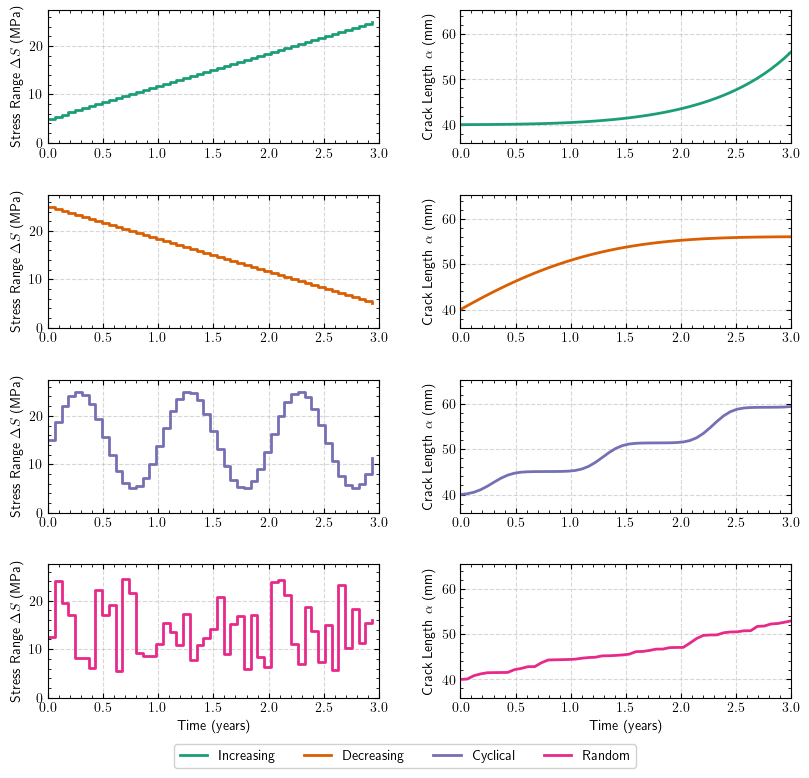

In [19]:
from src.visualisation import plot_stress_pattern_comparison

# Set parameters
logc = np.log(5e-14)  # Natural log of Paris law C parameter
m = 3.2               # Paris law exponent m
navg = 2.8e6          # Average cycles per year
a0 = 40.0             # Initial crack length (mm)

# Use the new function to create the comparison plot
fig, axes, stats = plot_stress_pattern_comparison(
    logc=logc,
    m=m,
    navg=navg,
    a0=a0,
    min_stress=5.0,
    max_stress=25.0,
    patterns=['increasing', 'decreasing', 'cyclical', 'random'],
    cmap_name='Dark2',
    figsize=(8.2, 8.2),
    save_fig_name="stress_pattern_comparison.pdf"
)

# Print analysis of the results
print("Final crack lengths with varying stress patterns:")
for pattern, length in stats['final_lengths'].items():
    print(f"{pattern.capitalize():<12}: {length:.2f} mm")

print("\nAverage stress for each pattern:")
for pattern, avg_stress in stats['avg_stresses'].items():
    print(f"{pattern.capitalize():<12}: {avg_stress:.2f} MPa")

# print("\nEffect of stress pattern (Length/Stress ratio):")
# for pattern, ratio in stats['length_stress_ratio'].items():
#     print(f"{pattern.capitalize():<12}: {ratio:.2f}")

# # Explanation of why patterns with same average stress produce different results
# print("\nObservation: Even with the same average stress, patterns produce")
# print(r"different final crack lengths because of the power law $(da/dN ∝ \Delta K^m)$.")
# print(f"When $m > 1$ (here m = {m:.1f}), high stress periods contribute")
# print("disproportionately more to crack growth than low stress periods.")


## Visualizing Selected Crack Growth Trajectories

Here we demonstrate the new functions for visualizing selected trajectories and observations.

In [20]:
# Import our new trajectory selector and observation generator
from src.data_utils import TrajectorySelector, CrackObservationGenerator
from src.visualisation import plot_selected_trajectories, plot_trajectories_with_observations

In [21]:
# First, let's select some trajectories with similar Paris law parameters
trajectory_selector = TrajectorySelector(data)

# Set target parameters for selection (similar to what we did in the HBM_for_SCG notebook)
# This will internally calculate target parameters based on the data statistics
trajectory_selector._set_target_parameters(scale_logc=-1.5, scale_m=1.5)

# Select trajectories that are within 1% of the standard deviation from the targets
selected_indices = trajectory_selector.select_by_radius(radius=0.01)
print(f"Found {len(selected_indices)} trajectories matching the criteria")

# Extract the selected trajectories
selected_trajectories = trajectory_selector.extract_trajectories(selected_indices)

# Print Paris parameters of selected trajectories
print("Paris parameters of selected trajectories:")
for i, (c, m) in enumerate(zip(selected_trajectories['paris_c'], selected_trajectories['paris_m'])):
    print(f"Trajectory {i+1}: C={c:.2e}, m={m:.4f}")

Found 3 trajectories matching the criteria
Paris parameters of selected trajectories:
Trajectory 1: C=4.80e-14, m=3.2491
Trajectory 2: C=4.82e-14, m=3.2482
Trajectory 3: C=4.79e-14, m=3.2494


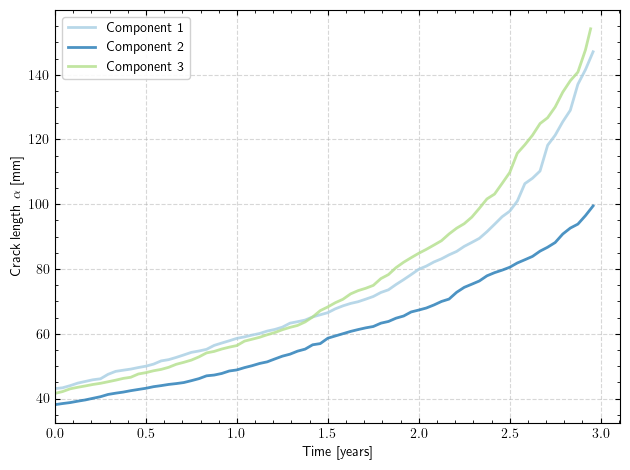

In [22]:
# Visualize the selected trajectories
fig, ax = plot_selected_trajectories(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    alpha=0.8,
    save_fig_name="selected_trajectories.pdf"
)

## Simulating and Visualizing Crack Observations

Now let's generate simulated observations from these trajectories and visualize them.

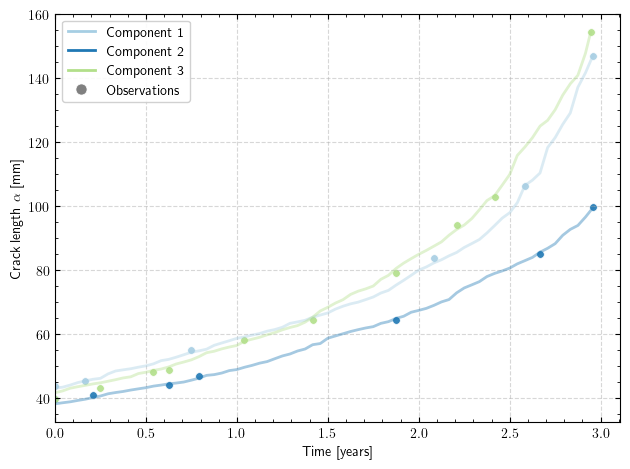

In [23]:
# Create an observation generator based on the selected trajectories
obs_generator = CrackObservationGenerator(selected_trajectories, random_seed=42)

# Generate observations using random sampling with noise
observations = obs_generator.create_observations(
    n_points=[6, 7, 10],           # 10 observations per trajectory
    strategy='random',     # Random sampling across the timeline
    std_dev=1.0,           # 1mm standard deviation measurement noise
    include_endpoints=True,  # Always include start and end points
    random_seed=42
)

# Visualize the trajectories with observations
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=observations['times'],
    obs_lengths=observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,        # Make the trajectories slightly transparent
    obs_alpha=0.9,         # Make the observations more visible
    marker_size=30,        # Increase marker size for visibility
    save_fig_name="trajectories_with_observations.pdf"
)

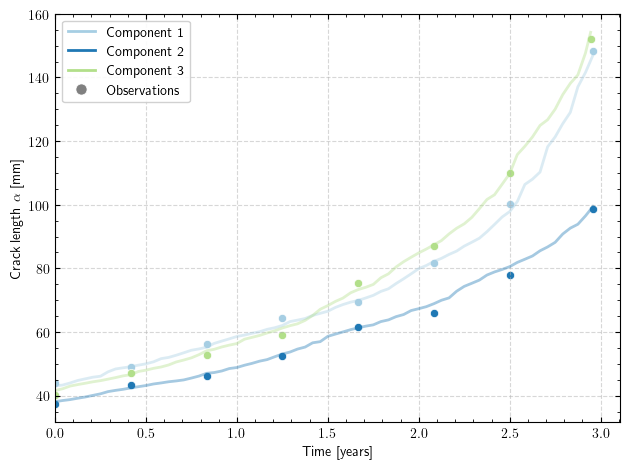

In [24]:
# Let's also try uniform sampling, which is more systematic
uniform_observations = obs_generator.create_observations(
    n_points=8,            # 8 observations per trajectory
    strategy='uniform',    # Evenly spaced observations
    std_dev=1.5,           # Slightly higher noise for demonstration
    include_endpoints=True,
    random_seed=42
)

# Visualize with uniform sampling
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=uniform_observations['times'],
    obs_lengths=uniform_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,
    obs_alpha=1.0,
    marker_size=35,
    save_fig_name="uniform_observations.pdf"
)

# Add title to indicate this is uniform sampling
# ax.set_title("Crack Growth Trajectories with Uniformly Sampled Observations")

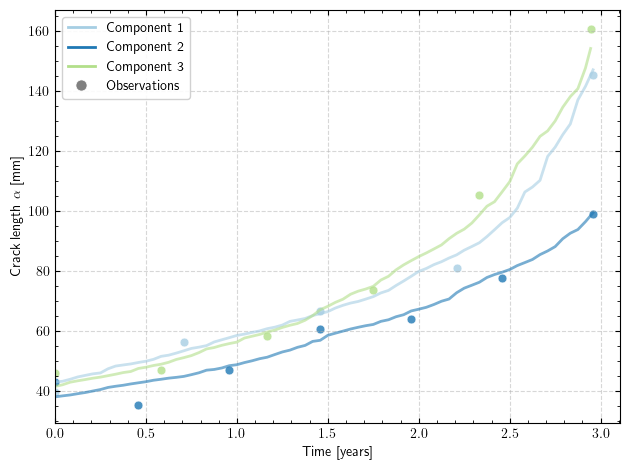

In [25]:
# Finally, let's demonstrate different noise levels
# Higher noise to illustrate measurement uncertainty
high_noise_observations = obs_generator.create_observations(
    n_points=[5, 7, 6],    # Different number of points for each trajectory
    strategy='uniform',
    std_dev=3.0,           # Higher noise level
    include_endpoints=True,
    random_seed=123
)

fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=high_noise_observations['times'],
    obs_lengths=high_noise_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=0.8,
    marker_size=40,
    save_fig_name="high_noise_observations.pdf"
)

# Add title to indicate the high noise level
# ax.set_title(r"Crack Growth Trajectories with High Measurement Uncertainty ($\sigma = 3.0$ mm)")

# Add text to explain what's being shown
# ax.text(0.02, 0.02, 
#         "Solid lines: True crack growth trajectories\nPoints: Simulated measurements with noise", 
#         transform=ax.transAxes, 
#         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
#         fontsize=9)

## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [52]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace

# Set a seed for reproducibility
np.random.seed(42)

In [56]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.Normal(3.2, 0.5),           # Paris law exponent
    "ds": dist.Gamma(5.0, 0.3),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

# Component index to start with
component_idx = 2

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][component_idx])
true_m = selected_trajectories['paris_m'][component_idx]
true_a0 = selected_trajectories['initial_crack_length'][component_idx]

print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")

True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


In [57]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:268: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 4000/4000 [00:01<00:00, 2119.29it/s, 1023 steps of size 1.91e-03. acc. prob=0.78]


In [58]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                                mean      sd    hdi_3%   hdi_97%  mcse_mean  \
ds                            9.9669  4.0118    3.5053   17.5874     0.1444   
logc                        -31.9376  1.5957  -34.7681  -28.9233     0.0597   
m                             4.1098  0.1556    3.8296    4.4081     0.0053   
noise_std                     1.4069  0.5034    0.7412    2.4151     0.0177   
predicted_crack_lengths[0]   46.6360  0.1559   46.3696   46.9407     0.0053   
predicted_crack_lengths[1]   53.0147  0.3389   52.4410   53.6888     0.0114   
predicted_crack_lengths[2]   61.3130  0.5452   60.3560   62.3726     0.0181   
predicted_crack_lengths[3]   72.4888  0.7551   71.1577   73.9572     0.0247   
predicted_crack_lengths[4]   88.2655  0.9102   86.6111   89.9926     0.0283   
predicted_crack_lengths[5]  111.8968  0.8930  110.2667  113.6238     0.0215   
predicted_crack_lengths[6]  153.0170  1.5198  150.2122  155.8404     0.0326   

                            mcse_sd   ess_bulk   es

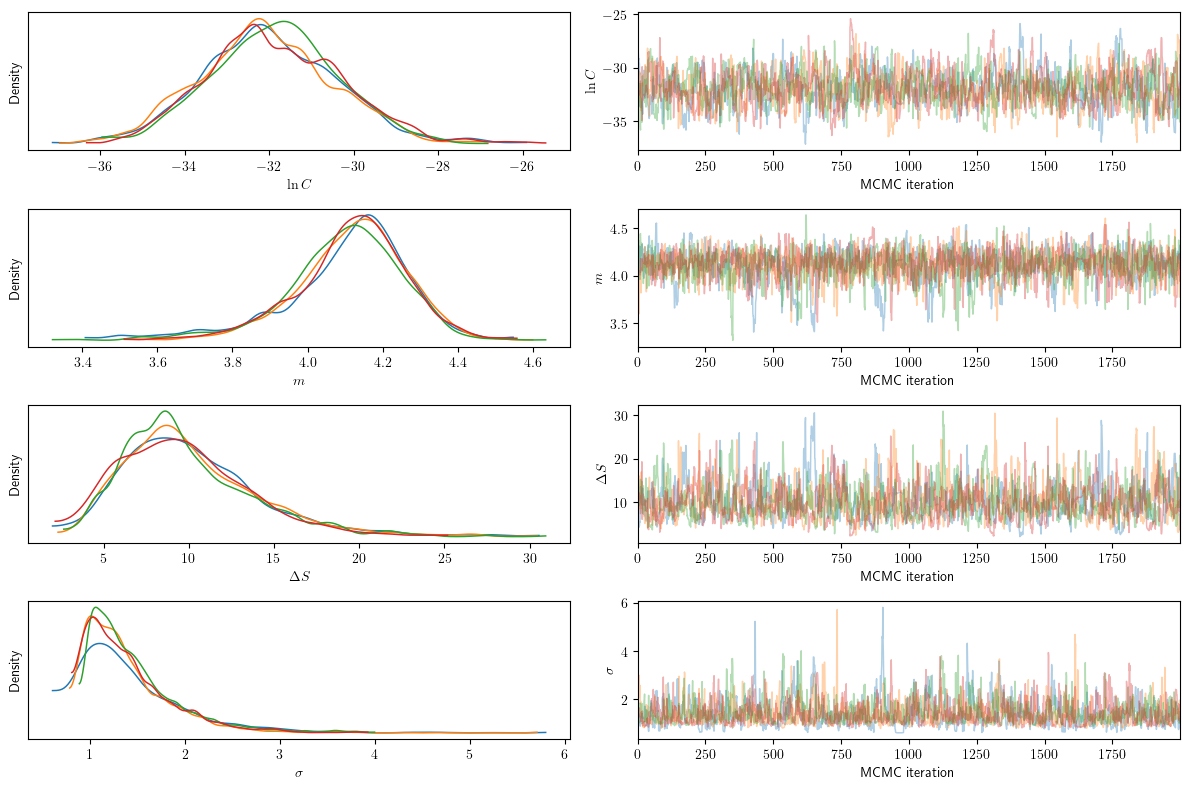

In [59]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_posterior_trace(results['samples'], var_names=var_names, save_fig_name="posterior_traces.pdf")

In [48]:
import matplotlib.pyplot as plt

In [51]:
# Generate posterior predictions
posterior_predictions = model.generate_predictions(num_samples=1000,
                                                   component_idx=component_idx,
                                                   navg=2.8e6,
                                                   random_seed=42)


# Extract predicted crack lengths
predicted_crack_lengths = posterior_predictions['predicted_crack_lengths']

# Get the true times and crack lengths for this component
true_times = selected_trajectories['times'][component_idx]
true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
observed_times = uniform_observations['times'][component_idx]
observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]

# Plot the true trajectory, observations, and predictions
plt.figure(figsize=(10, 6))

# Plot posterior predictive samples
for i in range(min(20, predicted_crack_lengths.shape[0])):  # Show at most 20 samples
    plt.plot(true_times, predicted_crack_lengths[i], color='gray', alpha=0.3, zorder=1)

# Plot the true trajectory
plt.plot(true_times, true_crack_lengths, 'k-', linewidth=2, label='True trajectory', zorder=3)

# Plot the observations
plt.scatter(observed_times, observed_crack_lengths, color='blue', s=50, label='Observations', zorder=4)

plt.xlabel('Time (years)')
plt.ylabel('Crack length (mm)')
plt.title('Posterior Predictive Check')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(bottom=0)

# Save the figure
# plt.savefig(Path(project_root) / "outputs" / "posterior_predictive.pdf", bbox_inches='tight')
plt.show()

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:374: UserWarning: Sample's batch dimension size 4 is different from the provided 1000 num_samples argument. Defaulting to 4.
  )


ValueError: Cannot broadcast to shape with fewer dimensions: arr_shape=(2000,) shape=()

In [ ]:
# Now let's run the model on all three components to compare performance
component_results = []

for i in range(len(selected_indices)):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(selected_trajectories['paris_c'][i])
    true_m = selected_trajectories['paris_m'][i]
    true_a0 = selected_trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)
    results = model.run_inference(
        component_idx=i,
        num_warmup=500,
        num_samples=1000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0
        },
        'inferred_params': {
            'logc': results['summary']['logc']['mean'],
            'logc_sd': results['summary']['logc']['sd'],
            'm': results['summary']['m']['mean'],
            'm_sd': results['summary']['m']['sd'],
            'ds': results['summary']['ds']['mean'],
            'ds_sd': results['summary']['ds']['sd'],
            'noise_std': results['summary']['noise_std']['mean'],
            'noise_std_sd': results['summary']['noise_std']['sd']
        }
    })

# Create a comparison table
pd.set_option('display.precision', 4)
comparison_df = pd.DataFrame([
    {
        'Component': i+1,
        'True logC': res['true_params']['logc'],
        'Inferred logC': res['inferred_params']['logc'],
        'logC Error (%)': 100 * (res['inferred_params']['logc'] - res['true_params']['logc']) / abs(res['true_params']['logc']),
        'True m': res['true_params']['m'],
        'Inferred m': res['inferred_params']['m'],
        'm Error (%)': 100 * (res['inferred_params']['m'] - res['true_params']['m']) / res['true_params']['m'],
        'Inferred noise_std': res['inferred_params']['noise_std']
    }
    for i, res in enumerate(component_results)
])

print("\nComparison of true vs inferred parameters:")
comparison_df